In [58]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict
from google import genai
from dotenv import load_dotenv
import os
from openai import OpenAI

In [59]:
class AgentState(TypedDict):
    question: str
    response: str
    clean_question: str

client = genai.Client()

load_dotenv(override=True)

client = OpenAI(
        base_url="https://router.huggingface.co/v1",
        api_key=os.environ["HF_TOKEN"],
    )

def call_llm(prompt: str):
    completion = client.chat.completions.create(
        model="meta-llama/Llama-3.1-8B-Instruct:novita",
        messages=[
            {
                "role": "user",
                "content": prompt
            }
        ],
    )
    return completion.choices[0].message.content

In [60]:
def questionCleaner(state: AgentState)-> AgentState:

    cleaner_prompt = f"""
    You are a helpful assistant that rewrites user questions clearly.

    Your task:
    - Convert the given question into a clear, complete, and grammatically correct question.
    - Keep the meaning exactly the same.
    - Do not add extra information.
    - Keep it concise.

    Return ONLY the rewritten question.

    User question:
    {state['question']}
    """

    clean_question = call_llm(cleaner_prompt)

    state['clean_question'] = clean_question
    return state

def responseGenerator(state: AgentState)-> AgentState:
    generator_prompt = f"""
    You are a helpful assistant.

    Your task:
    - Answer the given question clearly and accurately.
    - Keep the answer concise and easy to understand.
    - Use simple language.
    - Do not include unnecessary explanations.

    Format:
    - Provide the answer in 4 to 5 bullet points.

    Question:
    {state['clean_question']}
    """

    answer = call_llm(generator_prompt)

    state['response'] = answer
    return state


In [61]:
graph = StateGraph(AgentState)
graph.add_node("question_cleaner", questionCleaner)
graph.add_node("response_generator", responseGenerator)

graph.add_edge(START, "question_cleaner")
graph.add_edge("question_cleaner", "response_generator")
graph.add_edge("response_generator", END)

app = graph.compile()

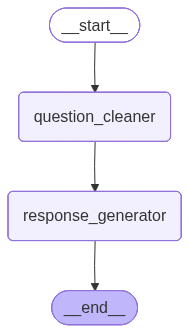

In [62]:
from IPython.display import display, Image
display(Image(app.get_graph().draw_mermaid_png()))

In [63]:
answer = app.invoke({'question': 'what is AI'})
print(answer['response'])

Here are 5 key points about Artificial Intelligence (AI):

* Artificial Intelligence (AI) is the development of computer systems that can think and learn like humans.
* AI systems can process and analyze large amounts of data to make decisions and solve problems.
* AI uses algorithms and machine learning to improve its performance over time.
* AI can perform tasks such as speech recognition, image recognition, and natural language processing.
* The main goal of AI is to create intelligent machines that can assist and augment human capabilities.
